# Hierarchical clustering
- used for Exploatory data analysis

In [70]:
# Hierarchical Clustering on Iris Dataset

from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler

# sckit-learn doesn’t give a dendrogram by default (but you can approximate one from the linkage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import matplotlib.pyplot as plt

In [71]:
# 1. (OPTIONAL)Load the Iris dataset suing scikit learn 
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for clarity
df = pd.DataFrame(X, columns=feature_names)
df['actual_label'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   actual_label  
0             0  
1             0  
2             0  
3             0  
4             0  


In [72]:
df = pd.read_csv("data_iris_without_labels.csv")
print(df.sample(10))

    sepal_length  sepal_width  petal_length  petal_width
84           5.4          3.0           4.5          1.5
40           5.0          3.5           1.3          0.3
5            5.4          3.9           1.7          0.4
75           6.6          3.0           4.4          1.4
32           5.2          4.1           1.5          0.1
95           5.7          3.0           4.2          1.2
85           6.0          3.4           4.5          1.6
74           6.4          2.9           4.3          1.3
31           5.4          3.4           1.5          0.4
52           6.9          3.1           4.9          1.5


In [73]:
# 2. Standardize the data (VERY IMPORTANT for HC). TODO Remove the column actual label
scaler = StandardScaler()

# scaler.fit(df)
# X_scaled = scaler.transform(df)

X_scaled = scaler.fit_transform(df)

# print first 10 values of scaled data
print(X_scaled[:10])

[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]
 [-0.53717756  1.95766909 -1.17067529 -1.05003079]
 [-1.50652052  0.80065426 -1.3412724  -1.18150376]
 [-1.02184904  0.80065426 -1.2844067  -1.31297673]
 [-1.74885626 -0.35636057 -1.3412724  -1.31297673]
 [-1.14301691  0.10644536 -1.2844067  -1.4444497 ]]


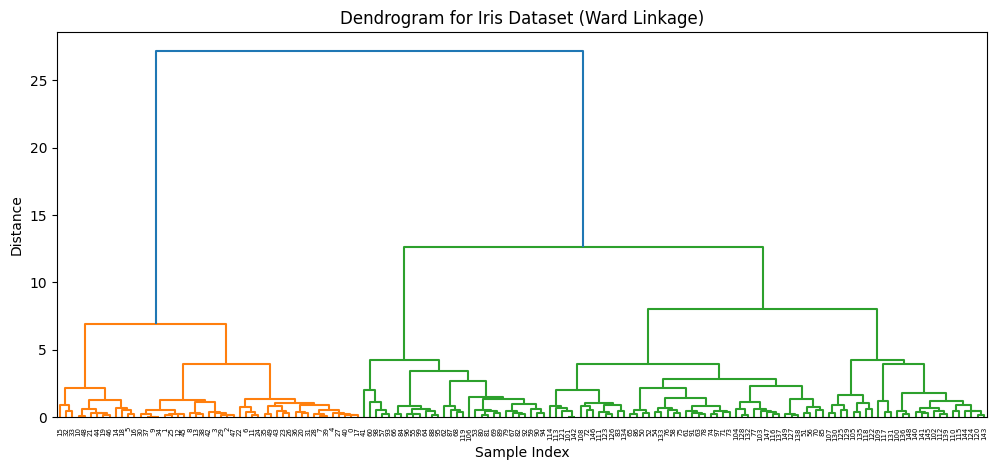

In [74]:

# 3. Perform hierarchical clustering (Ward linkage)
Z = linkage(X_scaled, method='ward')

# 4. Plot dendrogram
plt.figure(figsize=(12, 5))
plt.title("Dendrogram for Iris Dataset (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(Z)
plt.show()

# Look for long vertical lines not crossed by any horizontal line.
# The number of vertical branches below the cut is the number of clusters.
# For the Iris dataset, you typically see 3 large branches → 3 natural clusters.

In [75]:
# 4. Predict clusters (k = 3)
clusters = fcluster(Z, t=3, criterion='maxclust')
df['predicted_cluster'] = clusters
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  predicted_cluster
0           5.1          3.5           1.4          0.2                  1
1           4.9          3.0           1.4          0.2                  1
2           4.7          3.2           1.3          0.2                  1
3           4.6          3.1           1.5          0.2                  1
4           5.0          3.6           1.4          0.2                  1


In [76]:
print(df["predicted_cluster"].nunique())
print(df["predicted_cluster"].unique())
print(df["predicted_cluster"].value_counts())


3
[1 2 3]
predicted_cluster
3    71
1    49
2    30
Name: count, dtype: int64


In [77]:
# 5. Scatter plots: Actual vs Predicted

In [78]:
df_actual = pd.read_csv("data_iris_with_labels.csv")
print(df_actual.sample(10))

     sepal_length  sepal_width  petal_length  petal_width     species
87            6.3          2.3           4.4          1.3  versicolor
0             5.1          3.5           1.4          0.2      setosa
130           7.4          2.8           6.1          1.9   virginica
82            5.8          2.7           3.9          1.2  versicolor
96            5.7          2.9           4.2          1.3  versicolor
19            5.1          3.8           1.5          0.3      setosa
133           6.3          2.8           5.1          1.5   virginica
61            5.9          3.0           4.2          1.5  versicolor
78            6.0          2.9           4.5          1.5  versicolor
107           7.3          2.9           6.3          1.8   virginica


In [79]:
df['actual_species'] = df_actual['species']
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width  predicted_cluster  \
127           6.1          3.0           4.9          1.8                  3   
24            4.8          3.4           1.9          0.2                  1   
109           7.2          3.6           6.1          2.5                  3   
31            5.4          3.4           1.5          0.4                  1   
77            6.7          3.0           5.0          1.7                  3   
75            6.6          3.0           4.4          1.4                  3   
85            6.0          3.4           4.5          1.6                  3   
25            5.0          3.0           1.6          0.2                  1   
139           6.9          3.1           5.4          2.1                  3   
117           7.7          3.8           6.7          2.2                  3   

    actual_species  
127      virginica  
24          setosa  
109      virginica  
31          setosa  
77      versic

In [80]:
# Encode actual labels
label_map = {
    'setosa': 1,
    'versicolor': 2,
    'virginica': 3
}

df['species_label'] = df['actual_species'].map(label_map)
print(df.sample(10))

     sepal_length  sepal_width  petal_length  petal_width  predicted_cluster  \
37            4.9          3.1           1.5          0.1                  1   
93            5.0          2.3           3.3          1.0                  2   
60            5.0          2.0           3.5          1.0                  2   
16            5.4          3.9           1.3          0.4                  1   
83            6.0          2.7           5.1          1.6                  3   
63            6.1          2.9           4.7          1.4                  3   
118           7.7          2.6           6.9          2.3                  3   
113           5.7          2.5           5.0          2.0                  3   
9             4.9          3.1           1.5          0.1                  1   
55            5.7          2.8           4.5          1.3                  2   

    actual_species  species_label  
37          setosa              1  
93      versicolor              2  
60      ver

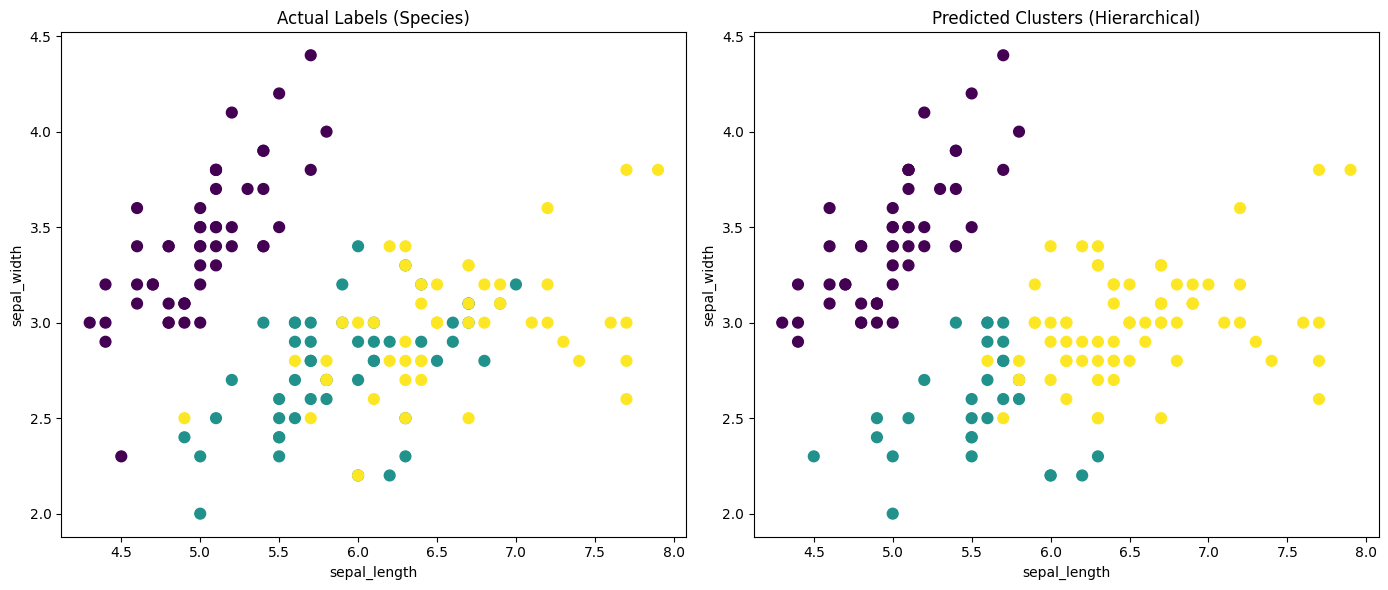

In [81]:
plt.figure(figsize=(14, 6))

colx = "sepal_length"
coly = "sepal_width"
x = df[colx]
y = df[coly]

# ----- LEFT PLOT (Actual Labels) -----
plt.subplot(1, 2, 1)
plt.scatter(x, y, c=df['species_label'], s=60)
plt.title("Actual Labels (Species)")
plt.xlabel(colx)
plt.ylabel(coly)

# ----- RIGHT PLOT (Predicted Clusters) -----
plt.subplot(1, 2, 2)
plt.scatter(x, y, c=df['predicted_cluster'], s=60)
plt.title("Predicted Clusters (Hierarchical)")
plt.xlabel(colx)
plt.ylabel(coly)

plt.tight_layout()
plt.show()

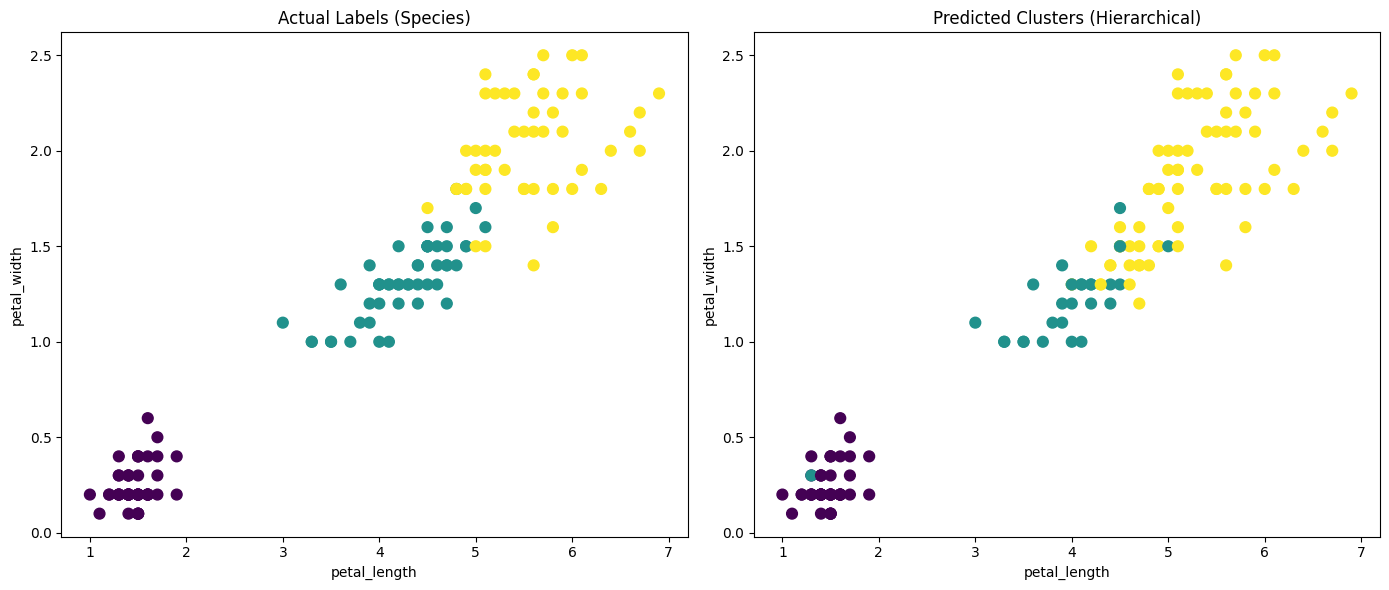

In [82]:
plt.figure(figsize=(14, 6))

colx = "petal_length"
coly = "petal_width"
x = df[colx]
y = df[coly]

# ----- LEFT PLOT (Actual Labels) -----
plt.subplot(1, 2, 1)
plt.scatter(x, y, c=df['species_label'], s=60)
plt.title("Actual Labels (Species)")
plt.xlabel(colx)
plt.ylabel(coly)

# ----- RIGHT PLOT (Predicted Clusters) -----
plt.subplot(1, 2, 2)
plt.scatter(x, y, c=df['predicted_cluster'], s=60)
plt.title("Predicted Clusters (Hierarchical)")
plt.xlabel(colx)
plt.ylabel(coly)

plt.tight_layout()
plt.show()

# How good is the model ?

In [83]:
# Use Adjusted Rand Index
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['actual_species'], df['predicted_cluster'])

print("ARI:", ari)

ARI: 0.6153229932145449


[[49  1  0]
 [ 0 27 23]
 [ 0  2 48]]
######################


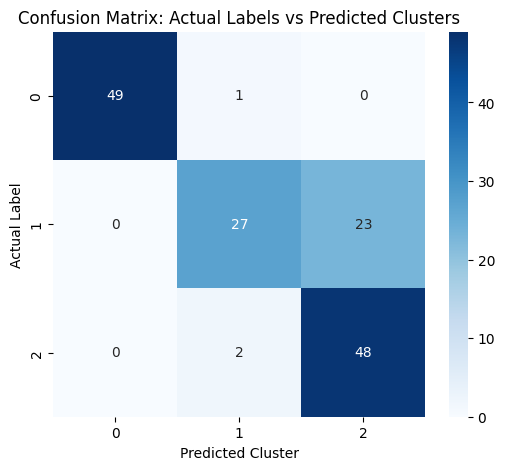

In [89]:
# OPTIONAL: Lets check accuracy, (although this metric does NOT make sense in clustering)

import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(df['species_label'], df['predicted_cluster'])
print(cm)

print("######################")
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)

plt.title("Confusion Matrix: Actual Labels vs Predicted Clusters")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Label")
plt.show()